In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install biopython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.3 MB/s eta 0:00:0000:0100:01


In [2]:
# =========================
# Install & load small ESM2 model (t6_8M) for GPU-friendly embedding
# =========================
!pip install fair-esm

import torch
import esm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load smaller ESM2 model (~8M params)
esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.to(device)
esm_model.eval()

batch_converter = esm_alphabet.get_batch_converter()
print("✅ Loaded ESM2-t6_8M model")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 1.3 MB/s eta 0:00:00a 0:00:01
Device: cuda
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
✅ Loaded ESM2-t6_8M model


In [3]:
# ==========================================================
# 📦 Libraries
# ==========================================================

import pandas as pd
import numpy as np
import torch
import esm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import rbf_kernel

import umap


# ==========================================================
# 📁 Load Data
# ==========================================================

pep_path  = "/kaggle/input/datasets/fateme65ghorbani/test-mmd/gen_650M.csv"
my_path   = "/kaggle/input/datasets/fateme65ghorbani/test-mmd/iptm-full-generated_peptides_teacher_scored.csv"
test_path = "/kaggle/input/datasets/fateme65ghorbani/test-mmd/test.csv"


pep_seqs = pd.read_csv(pep_path)['Binder'].astype(str).tolist()

test_seqs = pd.read_csv(test_path)['Binder'].astype(str).tolist()

my_df = pd.read_csv(my_path)

my_rank1_seqs = (
    my_df[my_df['Rank']==1]['Generated Peptide']
    .astype(str)
    .tolist()
)



# ==========================================================
# 🔹 Validity Filter
# ==========================================================

AA_set = set("ACDEFGHIKLMNPQRSTVWY")


def is_valid(seq):

    return (
        set(seq).issubset(AA_set)
        and 6 <= len(seq) <= 30
    )


pep_valid = [
    s for s in pep_seqs 
    if is_valid(s)
]


my_rank1_valid = [
    s for s in my_rank1_seqs
    if is_valid(s)
]


test_valid = [
    s for s in test_seqs
    if is_valid(s)
]


print("Valid sequences:")
print("PepMLM :", len(pep_valid))
print("cTAMP  :", len(my_rank1_valid))
print("Test   :", len(test_valid))



# ==========================================================
# 🧬 ESM2 Embedding
# ==========================================================


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()

esm_model = (
    esm_model
    .to(device)
    .eval()
)


batch_converter = esm_alphabet.get_batch_converter()



def embed_sequences(
        seqs,
        batch_size=32
):

    embeddings = []


    for i in range(
        0,
        len(seqs),
        batch_size
    ):

        batch = seqs[i:i+batch_size]


        _, _, tokens = batch_converter(
            [
                (str(j), s)
                for j,s in enumerate(batch)
            ]
        )


        tokens = tokens.to(device)


        with torch.no_grad():

            results = esm_model(
                tokens,
                repr_layers=[6],
                return_contacts=False
            )


        # CLS representation
        emb = (
            results["representations"][6][:,0]
            .cpu()
            .numpy()
        )


        embeddings.append(emb)



    return np.vstack(embeddings)



print("\nEmbedding Test...")
emb_test = embed_sequences(test_valid)


print("Embedding cTAMP...")
emb_my = embed_sequences(my_rank1_valid)


print("Embedding PepMLM...")
emb_pep = embed_sequences(pep_valid)




# ==========================================================
# 🔻 PCA Reduction
# ==========================================================


print("\n==============================")
print("PCA dimensionality reduction")
print("==============================")


X_all = np.vstack(
    [
        emb_test,
        emb_my,
        emb_pep
    ]
)


pca = PCA(
    n_components=50,
    random_state=42
)


X_pca = pca.fit_transform(X_all)



variance = (
    pca
    .explained_variance_ratio_
    .sum()
)


print(
    f"PCA components: 50"
)

print(
    f"Explained variance: {variance:.4f}"
)



# Separate PCA embeddings

emb_test_pca = X_pca[
    :len(emb_test)
]


emb_my_pca = X_pca[
    len(emb_test):
    len(emb_test)+len(emb_my)
]


emb_pep_pca = X_pca[
    len(emb_test)+len(emb_my):
]



print(
    "PCA completed successfully"
)

Valid sequences:
PepMLM : 108
cTAMP  : 145
Test   : 111

Embedding Test...
Embedding cTAMP...
Embedding PepMLM...

PCA dimensionality reduction
PCA components: 50
Explained variance: 0.9440
PCA completed successfully



Maximum Mean Discrepancy (MMD)
My Model Rank-1 vs Test : 0.054028
PepMLM vs Test          : 0.018191

✓ PepMLM is closer to Test distribution.

Bootstrap 95% Confidence Interval

My Model
----------------
Mean MMD : 0.060436
95% CI   : [0.044002, 0.079933]

PepMLM
----------------
Mean MMD : 0.025502
95% CI   : [0.012064, 0.041886]


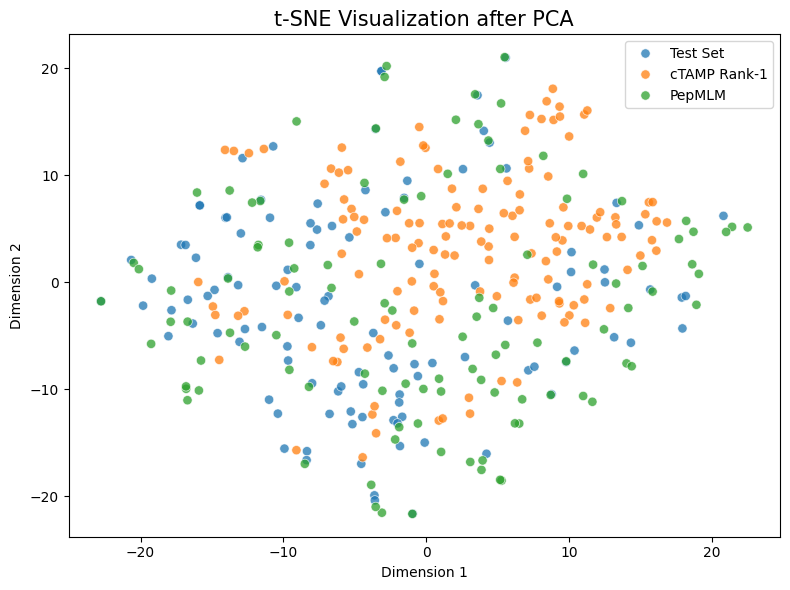

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


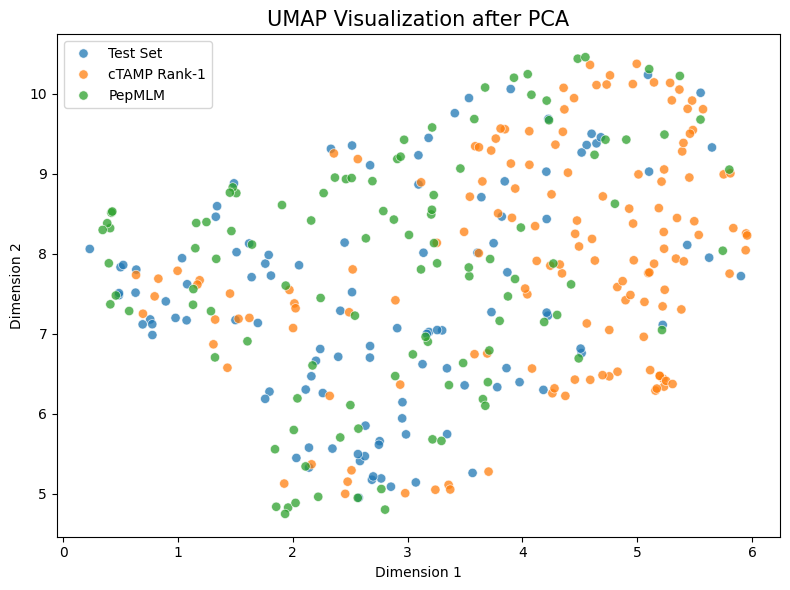


Cosine Similarity Summary
cTAMP  Mean=0.9851, Std=0.0054
PepMLM Mean=0.9818, Std=0.0110


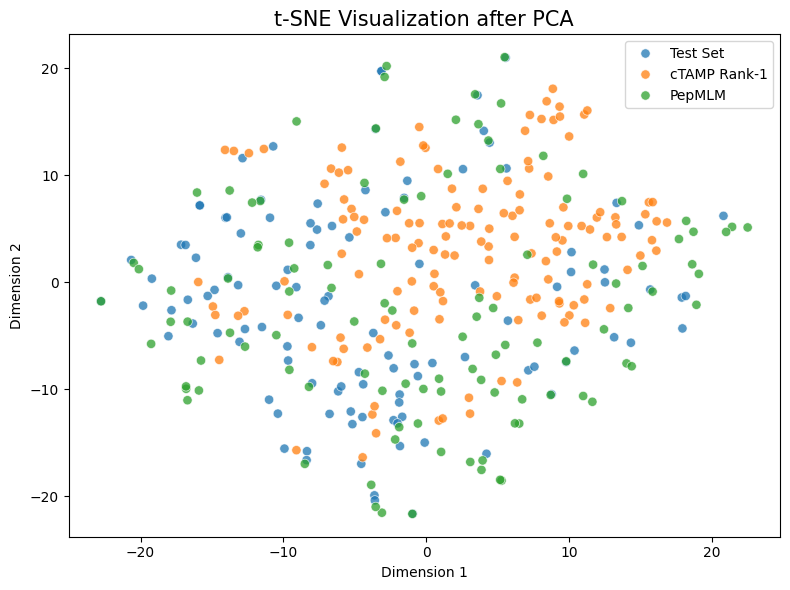

Saved: /kaggle/working/tSNE_PCA_embedding.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


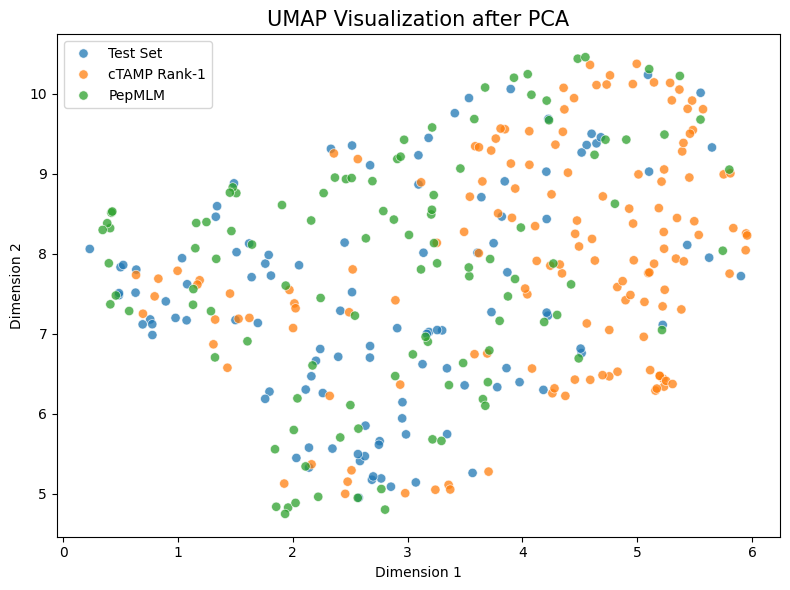

Saved: /kaggle/working/UMAP_PCA_embedding.png


In [5]:
# ==========================================================
# 🔹 MMD Analysis (using original ESM embeddings)
# ==========================================================

from sklearn.metrics.pairwise import rbf_kernel


def compute_mmd_rbf(X, Y, gamma=None):

    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)


    if gamma is None:

        Z = np.vstack([X, Y])

        dist2 = np.sum(
            (Z[:, None, :] - Z[None, :, :])**2,
            axis=-1
        )

        median = np.median(dist2[dist2 > 0])

        gamma = 1.0 / (2.0 * median)


    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)


    n = len(X)
    m = len(Y)


    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)


    mmd = (
        Kxx.sum()/(n*(n-1))
        +
        Kyy.sum()/(m*(m-1))
        -
        2*Kxy.mean()
    )


    return float(mmd), gamma



# -----------------------------
# Calculate MMD
# -----------------------------

mmd_my, gamma_my = compute_mmd_rbf(
    emb_my,
    emb_test
)


mmd_pep, gamma_pep = compute_mmd_rbf(
    emb_pep,
    emb_test
)


print("\n==============================")
print("Maximum Mean Discrepancy (MMD)")
print("==============================")

print(
    f"My Model Rank-1 vs Test : {mmd_my:.6f}"
)

print(
    f"PepMLM vs Test          : {mmd_pep:.6f}"
)


if mmd_my < mmd_pep:
    print("\n✓ cTAMP is closer to Test distribution.")

else:
    print("\n✓ PepMLM is closer to Test distribution.")





# ==========================================================
# 🔹 Bootstrap Confidence Interval for MMD
# ==========================================================


def bootstrap_mmd_ci(
        X,
        Y,
        gamma,
        n_bootstrap=1000,
        confidence=95,
        random_state=42
):

    rng = np.random.default_rng(random_state)

    scores=[]

    n=len(X)
    m=len(Y)


    for _ in range(n_bootstrap):

        X_boot = X[
            rng.integers(
                0,
                n,
                size=n
            )
        ]

        Y_boot = Y[
            rng.integers(
                0,
                m,
                size=m
            )
        ]


        mmd,_ = compute_mmd_rbf(
            X_boot,
            Y_boot,
            gamma=gamma
        )


        scores.append(mmd)


    scores=np.array(scores)


    alpha=(100-confidence)/2


    lower=np.percentile(
        scores,
        alpha
    )


    upper=np.percentile(
        scores,
        100-alpha
    )


    return (
        scores.mean(),
        lower,
        upper
    )




print("\n===================================")
print("Bootstrap 95% Confidence Interval")
print("===================================")



mean_my, low_my, high_my = bootstrap_mmd_ci(
    emb_my,
    emb_test,
    gamma_my
)



mean_pep, low_pep, high_pep = bootstrap_mmd_ci(
    emb_pep,
    emb_test,
    gamma_pep
)



print("\nMy Model")
print("----------------")
print(
    f"Mean MMD : {mean_my:.6f}"
)

print(
    f"95% CI   : [{low_my:.6f}, {high_my:.6f}]"
)



print("\nPepMLM")
print("----------------")

print(
    f"Mean MMD : {mean_pep:.6f}"
)

print(
    f"95% CI   : [{low_pep:.6f}, {high_pep:.6f}]"
)





# ==========================================================
# 🔹 t-SNE and UMAP Visualization
#    Using PCA-reduced embeddings
# ==========================================================


def plot_embedding(
        X_pca,
        labels,
        method="t-SNE"
):


    if method=="t-SNE":

        X_emb = TSNE(
            n_components=2,
            perplexity=30,
            random_state=42
        ).fit_transform(X_pca)


    else:

        X_emb = umap.UMAP(
            n_neighbors=30,
            min_dist=0.1,
            random_state=42
        ).fit_transform(X_pca)



    df_plot=pd.DataFrame(
        {
            "Dim1":X_emb[:,0],
            "Dim2":X_emb[:,1],
            "Source":labels
        }
    )


    plt.figure(
        figsize=(8,6)
    )


    sns.scatterplot(
        data=df_plot,
        x="Dim1",
        y="Dim2",
        hue="Source",
        s=45,
        alpha=0.75
    )


    plt.title(
        f"{method} Visualization after PCA",
        fontsize=15
    )


    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")

    plt.legend()

    plt.tight_layout()

    plt.show()




# Labels

labels = (
    ["Test Set"]*len(emb_test)
    +
    ["cTAMP Rank-1"]*len(emb_my)
    +
    ["PepMLM"]*len(emb_pep)
)



# t-SNE

plot_embedding(
    X_pca,
    labels,
    "t-SNE"
)



# UMAP

plot_embedding(
    X_pca,
    labels,
    "UMAP"
)





# ==========================================================
# 🔹 Cosine Similarity to Test Set
# ==========================================================


def cosine_similarity(A,B):

    A_norm = (
        A /
        np.linalg.norm(
            A,
            axis=1,
            keepdims=True
        )
    )

    B_norm = (
        B /
        np.linalg.norm(
            B,
            axis=1,
            keepdims=True
        )
    )


    return A_norm @ B_norm.T




sim_my = cosine_similarity(
    emb_my,
    emb_test
).max(axis=1)



sim_pep = cosine_similarity(
    emb_pep,
    emb_test
).max(axis=1)



print("\n===================================")
print("Cosine Similarity Summary")
print("===================================")


print(
    f"cTAMP  Mean={sim_my.mean():.4f}, "
    f"Std={sim_my.std():.4f}"
)


print(
    f"PepMLM Mean={sim_pep.mean():.4f}, "
    f"Std={sim_pep.std():.4f}"
)
# ==========================================================
# 💾 Save t-SNE and UMAP Figures
# ==========================================================

import os

save_dir = "/kaggle/working/"

os.makedirs(save_dir, exist_ok=True)



def save_embedding_plot(
        X_pca,
        labels,
        method,
        filename
):

    if method == "t-SNE":

        X_emb = TSNE(
            n_components=2,
            perplexity=30,
            random_state=42
        ).fit_transform(X_pca)


    elif method == "UMAP":

        X_emb = umap.UMAP(
            n_neighbors=30,
            min_dist=0.1,
            random_state=42
        ).fit_transform(X_pca)



    df_plot = pd.DataFrame(
        {
            "Dim1": X_emb[:,0],
            "Dim2": X_emb[:,1],
            "Source": labels
        }
    )


    plt.figure(figsize=(8,6))


    sns.scatterplot(
        data=df_plot,
        x="Dim1",
        y="Dim2",
        hue="Source",
        s=45,
        alpha=0.75
    )


    plt.title(
        f"{method} Visualization after PCA",
        fontsize=15
    )

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")

    plt.legend(
        frameon=True
    )

    plt.tight_layout()



    save_path = os.path.join(
        save_dir,
        filename
    )


    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    print(
        f"Saved: {save_path}"
    )




# ===============================
# Save t-SNE
# ===============================

save_embedding_plot(
    X_pca,
    labels,
    "t-SNE",
    "tSNE_PCA_embedding.png"
)



# ===============================
# Save UMAP
# ===============================

save_embedding_plot(
    X_pca,
    labels,
    "UMAP",
    "UMAP_PCA_embedding.png"
)